In [71]:
#setting up environment

!pip install pandas numpy matplotlib scikit-learn xgboost shap

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

In [73]:
# downloaded dataset from - https://www.kaggle.com/datasets/TheAquarianInventor/commodity-price-dataset

In [74]:
import pandas as pd

df = pd.read_csv("Commodity1_price.csv")

In [75]:
# inspecting dataset
df.head(10)

,Unnamed: 0,days_anomal,State,Market,Variety,Grade,Arrival,MinimumPrice,ModalPrice,MaximumPrice
0,0,2007-01-06,place1,Place0,type0,item14,0.40,2300.0,2400.0,2500.0
1,1,2007-01-06,place1,Place1,type0,item14,0.60,2800.0,NaN,2900.0
2,2,2007-01-06,place1,Place2,type0,item15,1.40,5000.0,5500.0,6000.0
3,3,2007-01-06,place1,Place2,type0,item14,0.00,4500.0,4800.0,5000.0
4,4,2007-01-06,place1,Place2,type0,item16,0.00,4000.0,4200.0,4500.0
5,5,2007-01-06,place1,Place3,type0,item14,0.03,2000.0,2500.0,2800.0
6,6,2007-01-06,place1,Place4,type0,item16,1.20,2500.0,NaN,3100.0
7,7,2007-01-06,place1,Place5,type1,item14,0.40,1800.0,2000.0,2200.0
8,8,2007-01-06,place1,Place6,type0,item14,1.50,2000.0,2500.0,3200.0
9,9,2007-01-06,place1,Place7,type0,item14,0.30,1500.0,1800.0,2200.0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520291 entries, 0 to 520290
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    520291 non-null  int64  
 1   days_anomal   520291 non-null  object 
 2   State         520291 non-null  object 
 3   Market        520291 non-null  object 
 4   Variety       520291 non-null  object 
 5   Grade         520291 non-null  object 
 6   Arrival       520291 non-null  float64
 7   MinimumPrice  462606 non-null  float64
 8   ModalPrice    506222 non-null  float64
 9   MaximumPrice  466146 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 39.7+ MB


In [77]:
df.columns

Index(['Unnamed: 0', 'days_anomal', 'State', 'Market', 'Variety', 'Grade',
       'Arrival', 'MinimumPrice', 'ModalPrice', 'MaximumPrice'],
      dtype='object')

In [78]:
df.isnull().sum()

,0
Unnamed: 0,0
days_anomal,0
State,0
Market,0
Variety,0
Grade,0
Arrival,0
MinimumPrice,57685
ModalPrice,14069
MaximumPrice,54145


In [79]:
df.shape

(520291, 10)

In [80]:
# data preprocessing for usage

df = df.rename(columns={
    "days_anomal": "date",
    "Arrival": "arrival",
    "ModalPrice": "price"
})

df["date"] = pd.to_datetime(df["date"])

df["Grade"].value_counts().head(20)

,count
Grade,
item14,381987
item16,72546
item15,47035
item17,18723


In [81]:
item14_df = df[
    df["Grade"] == "item14"
]

item14_df["Market"].value_counts().head(20)

,count
Market,
Place27,3641
Place43,3293
Place2,3239
Place124,3152
Place35,2789
Place110,2783
Place152,2754
Place41,2721
Place157,2692


In [82]:
item14_df = df[
    df["Grade"] == "item14"
].copy()

series_df = (
    item14_df
    .groupby("date")
    .agg({
        "price": "mean",
        "arrival": "mean",
        "MinimumPrice": "mean",
        "MaximumPrice": "mean"
    })
    .reset_index()
)

In [83]:
series_df = series_df.sort_values("date")

In [84]:
series_df.head()

,date,price,arrival,MinimumPrice,MaximumPrice
0,2007-01-06,2547.666667,4.137419,2247.321429,2742.857143
1,2007-01-07,2695.869565,4.204468,2380.227273,2950.681818
2,2007-01-08,2785.517857,15.460175,2363.096154,3069.557692
3,2007-01-09,2750.500000,12.141176,2330.804348,2929.347826
4,2007-01-10,2935.046512,7.375682,2677.125000,3220.125000


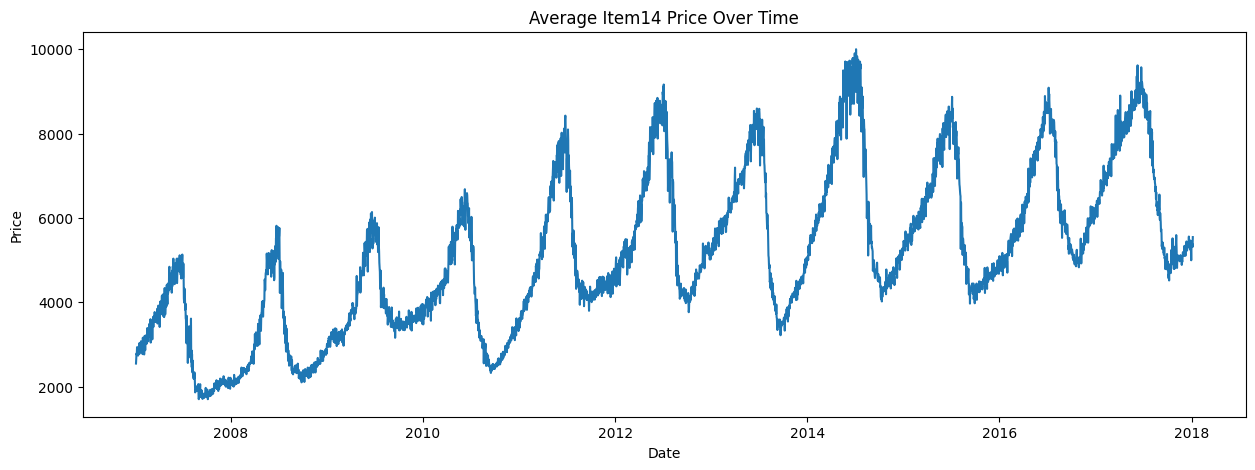

In [85]:
# visualizing the price trend over time

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    series_df["date"],
    series_df["price"]
)

plt.title("Average Item14 Price Over Time")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [86]:
series_df["date"].diff().value_counts().head(10)

,count
date,
1 days,4017


In [87]:
series_df.shape

(4018, 5)

In [88]:
series_df.isnull().sum()

,0
date,0
price,0
arrival,0
MinimumPrice,0
MaximumPrice,0


In [89]:
series_df["rolling_7"] = (
    series_df["price"]
    .rolling(7)
    .mean()
)

series_df["rolling_30"] = (
    series_df["price"]
    .rolling(30)
    .mean()
)

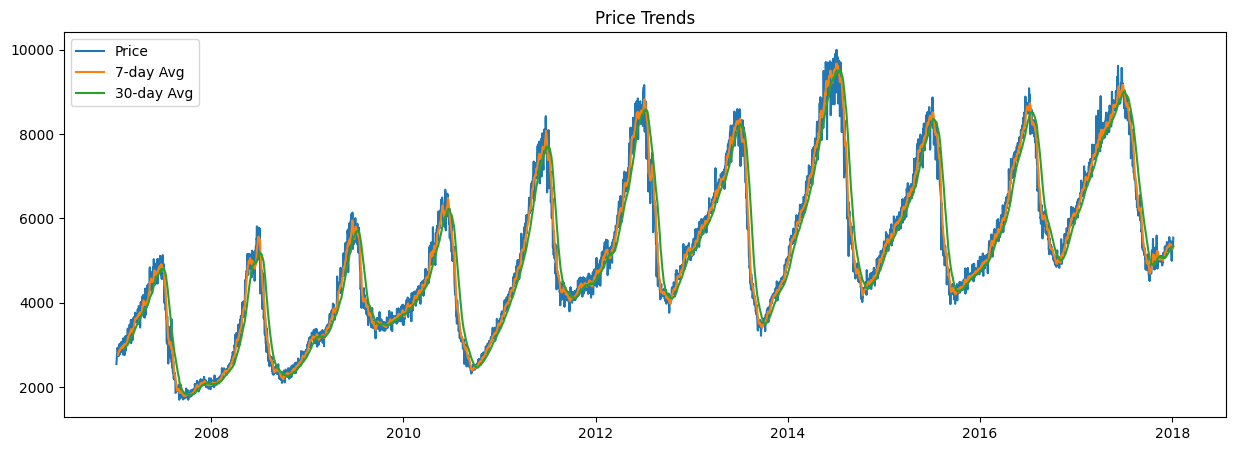

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(series_df["date"], series_df["price"], label="Price")

plt.plot(series_df["date"], series_df["rolling_7"], label="7-day Avg")

plt.plot(series_df["date"], series_df["rolling_30"], label="30-day Avg")

plt.legend()

plt.title("Price Trends")

plt.show()

In [91]:
series_df["rolling_std_7"] = (
    series_df["price"]
    .rolling(7)
    .std()
)

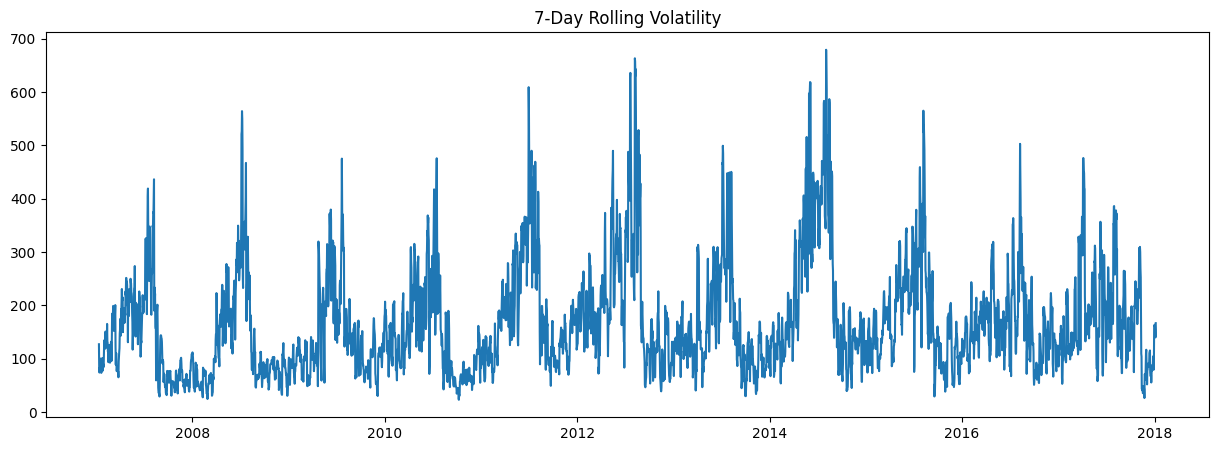

In [92]:
plt.figure(figsize=(15,5))

plt.plot(
    series_df["date"],
    series_df["rolling_std_7"]
)

plt.title("7-Day Rolling Volatility")

plt.show()

In [93]:
series_df["day_of_week"] = (
    series_df["date"]
    .dt.weekday
)

series_df["month"] = (
    series_df["date"]
    .dt.month
)

series_df["day_of_year"] = (
    series_df["date"]
    .dt.dayofyear
)

In [94]:
series_df["price_lag_1"] = (
    series_df["price"]
    .shift(1)
)

series_df["price_lag_7"] = (
    series_df["price"]
    .shift(7)
)

series_df["price_lag_30"] = (
    series_df["price"]
    .shift(30)
)

In [95]:
series_df["rolling_mean_7"] = (
    series_df["price"]
    .shift(1)
    .rolling(7)
    .mean()
)

series_df["rolling_mean_30"] = (
    series_df["price"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [96]:
series_df["rolling_std_7"] = (
    series_df["price"]
    .shift(1)
    .rolling(7)
    .std()
)

In [97]:
series_df["momentum_7"] = (
    series_df["price"]
    .shift(1)
    -
    series_df["price"]
    .shift(8)
)

In [98]:
series_df["price_pct_change_7"] = (
    series_df["price"]
    .pct_change(7)
)

In [99]:
series_df["arrival_lag_1"] = (
    series_df["arrival"]
    .shift(1)
)

series_df["arrival_rolling_7"] = (
    series_df["arrival"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [100]:
series_df = (
    series_df
    .dropna()
    .reset_index(drop=True)
)

In [101]:
series_df.head()

,date,price,arrival,MinimumPrice,MaximumPrice,rolling_7,rolling_30,rolling_std_7,day_of_week,month,day_of_year,price_lag_1,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30,momentum_7,price_pct_change_7,arrival_lag_1,arrival_rolling_7
0,2007-02-05,3014.743590,3.809500,2566.351351,3258.243243,3019.034739,2918.986943,121.649074,0,2,36,3031.031250,2952.410714,2547.666667,3010.130043,2903.417713,15.313859,0.021113,5.727879,6.916730
1,2007-02-06,2762.511111,3.216739,2402.707317,3007.880952,2976.970500,2921.208328,118.971769,1,2,37,3014.743590,3056.960784,2695.869565,3019.034739,2918.986943,62.332875,-0.096321,3.809500,6.351582
2,2007-02-07,2985.439024,6.428140,2631.775000,3230.100000,3007.621789,2927.872367,151.055110,2,2,38,2762.511111,2770.880000,2785.517857,2976.970500,2921.208328,-294.449673,0.077434,3.216739,5.684798
3,2007-02-08,3203.148936,4.907500,2847.952381,3388.309524,3013.885049,2942.960665,121.056315,3,2,39,2985.439024,3159.306122,2750.500000,3007.621789,2927.872367,214.559024,0.013877,6.428140,6.254585
4,2007-02-09,2965.857143,3.290000,2656.259259,3216.074074,3002.995593,2943.987686,130.942683,4,2,40,3203.148936,3042.083333,2935.046512,3013.885049,2942.960665,43.842814,-0.025057,4.907500,6.147342


In [102]:
series_df.shape

(3988, 20)

In [103]:
# defining model features

FEATURES = [
    "arrival",

    "day_of_week",
    "month",
    "day_of_year",

    "price_lag_1",
    "price_lag_7",
    "price_lag_30",

    "rolling_mean_7",
    "rolling_mean_30",

    "rolling_std_7",

    "momentum_7",

    "price_pct_change_7",

    "arrival_lag_1",
    "arrival_rolling_7"
]

In [104]:
TARGET = "price"

X = series_df[FEATURES]

y = series_df[TARGET]

In [105]:
# using some part of dataset for training, rest for predicting
split_idx = int(len(series_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [106]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(3190, 14)
(798, 14)
(3190,)
(798,)


In [107]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [108]:
model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [109]:
preds = model.predict(X_test)

In [110]:
preds[:10]

array([4522.7695, 4543.5054, 4564.0215, 4570.1655, 4545.4644, 4426.337 ,
       4771.8193, 4272.3696, 4546.1865, 4480.3657], dtype=float32)

In [111]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

mape = np.mean(
    np.abs(
        (y_test - preds) / y_test
    )
) * 100

In [112]:
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))
print("MAPE:", round(mape, 2), "%")

MAE : 70.23
RMSE: 94.2
R2  : 0.9954
MAPE: 1.08 %


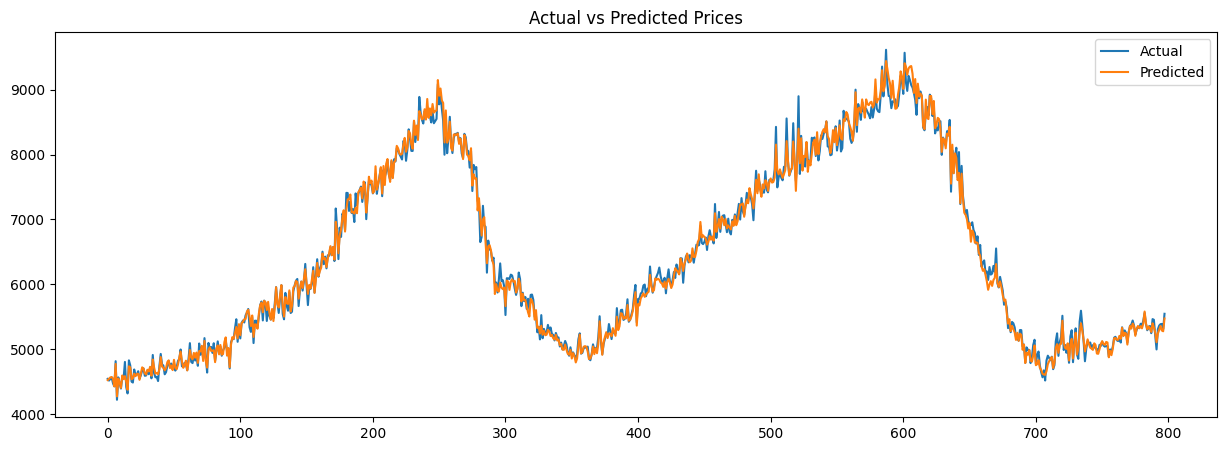

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    preds,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Prices")

plt.show()

In [114]:
residuals = y_test.values - preds

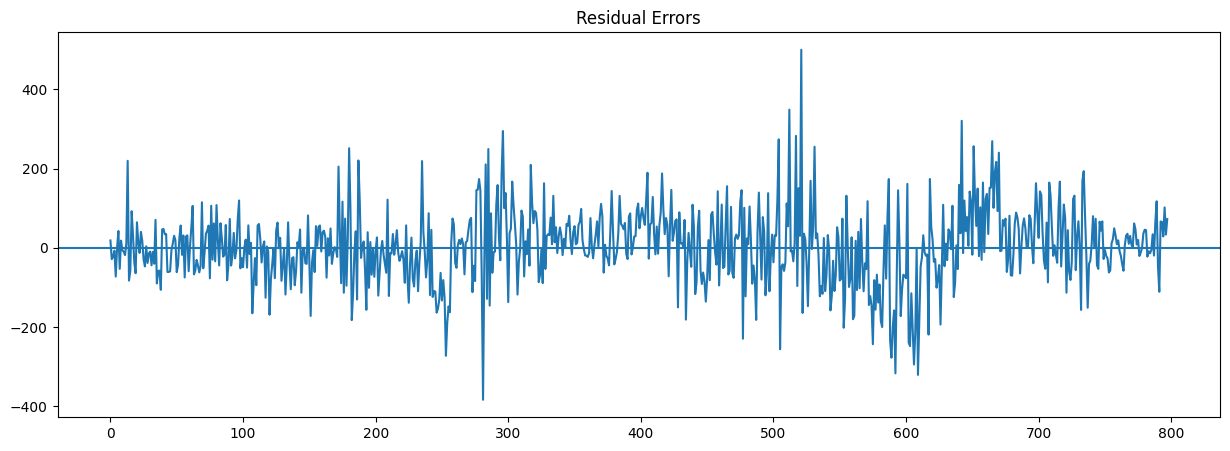

In [115]:
plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("Residual Errors")

plt.axhline(0)

plt.show()

In [116]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
})

In [117]:
importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

In [118]:
importance_df

,feature,importance
7,rolling_mean_7,0.819908
4,price_lag_1,0.152131
5,price_lag_7,0.018237
11,price_pct_change_7,0.004357
8,rolling_mean_30,0.000950
2,month,0.000937
3,day_of_year,0.000883
10,momentum_7,0.000541
6,price_lag_30,0.000502
13,arrival_rolling_7,0.000492


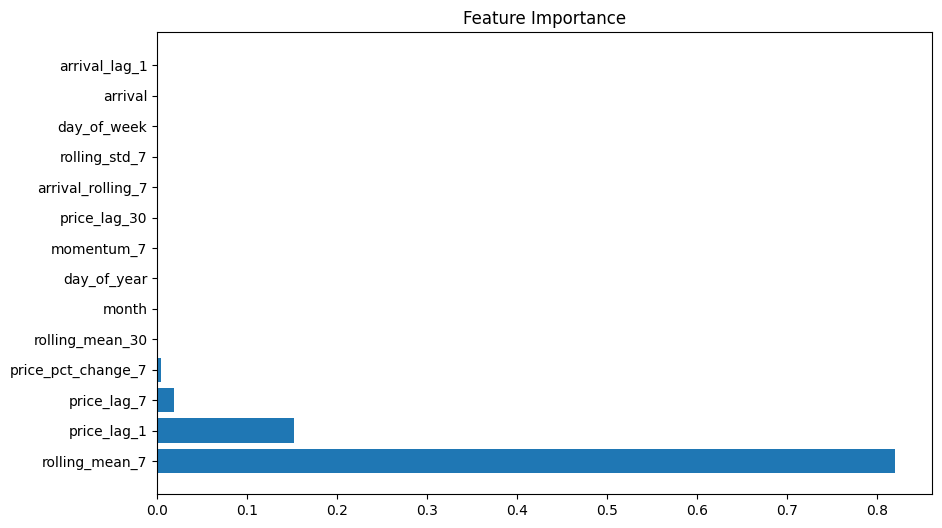

In [119]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title("Feature Importance")

plt.show()

In [120]:
import pickle
import json

In [121]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [122]:
with open("feature_cols.json", "w") as f:
    json.dump(FEATURES, f)

In [123]:
metrics = {
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2),
    "mape": float(mape)
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f)